In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Thesis/Datasets")
!pwd

/content/drive/MyDrive/Thesis/Datasets


In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

txt_file_path = "/content/drive/MyDrive/Thesis/Datasets/fent 2023 occurrence.txt"
xlsx_file_path = "/content/drive/MyDrive/Thesis/Datasets/fent_2023_occurrence.xlsx"

df = pd.read_csv(txt_file_path, delimiter="\t")
df.to_excel(xlsx_file_path, index=False)

print(f"Excel file saved at: {xlsx_file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Excel file saved at: /content/drive/MyDrive/Thesis/Datasets/fent_2023_occurrence.xlsx


In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

fent_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_fent_2023_occurrence.xlsx'

fent = pd.read_excel(fent_path)

fent['Month'] = fent['Month Code'].str.split('/').str[1].astype(int)

fent = fent.drop(columns=['Month Code'], errors='ignore')

fent.to_excel(fent_path, index=False)

print("Month column reformatted and file saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Month column reformatted and file saved.


In [ ]:
import pandas as pd
from google.colab import drive


drive.mount('/content/drive')

fent_2023_path = '/content/drive/MyDrive/Thesis/Datasets/fent_2023_occurrence.xlsx'
fent_2023 = pd.read_excel(fent_2023_path)

columns_to_remove = [
    'Notes',
    'Occurrence State Code',
    'Single Race 6 Code',
    'Year Code',
    'Ten-Year Age Groups Code',
    'Population',
    'Crude Rate'
]


fent_2023_cleaned = fent_2023.drop(columns=columns_to_remove, errors='ignore')


cleaned_file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_fent_2023_occurrence.xlsx'
fent_2023_cleaned.to_excel(cleaned_file_path, index=False)

print("Columns removed and cleaned dataset saved to:", cleaned_file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns removed and cleaned dataset saved to: /content/drive/MyDrive/Thesis/Datasets/cleaned_fent_2023_occurrence.xlsx


In [ ]:
import pandas as pd


file_path = "ACSST1Y2023.S1501-2025-03-12T152948.csv"
df = pd.read_csv(file_path)


df_cleaned = df.loc[:, ~df.columns.str.contains("male|female", case=False, regex=True)]


df_cleaned.to_csv("education.csv", index=False)

df_cleaned.head()


,Label (Grouping),Alabama!!Total!!Estimate,Alabama!!Percent!!Estimate,Alaska!!Total!!Estimate,Alaska!!Percent!!Estimate,Arizona!!Total!!Estimate,Arizona!!Percent!!Estimate,Arkansas!!Total!!Estimate,Arkansas!!Percent!!Estimate,California!!Total!!Estimate,...,Washington!!Total!!Estimate,Washington!!Percent!!Estimate,West Virginia!!Total!!Estimate,West Virginia!!Percent!!Estimate,Wisconsin!!Total!!Estimate,Wisconsin!!Percent!!Estimate,Wyoming!!Total!!Estimate,Wyoming!!Percent!!Estimate,Puerto Rico!!Total!!Estimate,Puerto Rico!!Percent!!Estimate
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"479,855",(X),"65,148",(X),"701,011",(X),"288,490",(X),"3,558,215",...,"654,491",(X),"159,210",(X),"550,661",(X),"50,239",(X),"299,750",(X)
2,Less than high school graduate,"51,796",10.8%,"8,523",13.1%,"97,858",14.0%,"37,090",12.9%,"347,978",...,"77,207",11.8%,"17,804",11.2%,"50,842",9.2%,"6,345",12.6%,"20,395",6.8%
3,High school graduate (includes equival...,"182,028",37.9%,"33,859",52.0%,"258,209",36.8%,"111,568",38.7%,"1,286,395",...,"249,390",38.1%,"69,202",43.5%,"208,435",37.9%,"20,119",40.0%,"87,889",29.3%
4,Some college or associate's degree,"194,385",40.5%,"19,964",30.6%,"265,769",37.9%,"108,757",37.7%,"1,459,490",...,"233,061",35.6%,"56,759",35.7%,"217,166",39.4%,"19,508",38.8%,"158,347",52.8%


In [ ]:
import pandas as pd

file_path = "/content/education:earnings.xlsx"
df = pd.read_excel(file_path, sheet_name=None)

for sheet in df:
    df[sheet].replace("#DIV/0!", "", inplace=True)

cleaned_file_path = "/content/cleaned_education_earnings.xlsx"
with pd.ExcelWriter(cleaned_file_path) as writer:
    for sheet_name, sheet_data in df.items():
        sheet_data.to_excel(writer, sheet_name=sheet_name, index=False)

from google.colab import files
files.download(cleaned_file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

file_path = "/content/cleaned_education_earnings.xlsx"
df = pd.read_excel(file_path, sheet_name=None)

for sheet in df:
    df[sheet].replace("#DIV/0!", "", inplace=True)
    state_columns = [col for col in df[sheet].columns if "Estimate" in col]
    percentage_columns = [col.replace("Estimate", "Percentage") for col in state_columns if col.replace("Estimate", "Percentage") in df[sheet].columns]
    df[sheet] = df[sheet][percentage_columns]
    df[sheet].columns = [col.replace(" Percentage", "").strip() for col in percentage_columns]

In [ ]:
import pandas as pd
from google.colab import files

file_path = "/content/cleaned_education_earnings.xlsx"
df = pd.read_excel(file_path, sheet_name=None)

for sheet in df:
    total_columns = [col for col in df[sheet].columns if "Total!!Estimate" in col]

    for col in total_columns:
        state_name = col.split("!!")[0]
        percent_col = col.replace("Total!!Estimate", "Percent!!Estimate")

        if percent_col in df[sheet].columns:
            df[sheet][state_name] = df[sheet][percent_col].combine_first(df[sheet][col])

    cols_to_drop = total_columns + [col.replace("Total!!Estimate", "Percent!!Estimate") for col in total_columns]
    df[sheet] = df[sheet].drop(columns=cols_to_drop, errors='ignore')

cleaned_file_path = "/content/final_education_earnings.xlsx"
with pd.ExcelWriter(cleaned_file_path) as writer:
    for sheet_name, sheet_data in df.items():
        sheet_data.to_excel(writer, sheet_name=sheet_name, index=False)

files.download(cleaned_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd


file_path = '/content/final_education_earnings.xlsx'
df = pd.read_excel(file_path)


transposed_df = df.transpose()


transposed_df.columns = transposed_df.iloc[0]
transposed_df = transposed_df[1:]


output_file_path = '/content/education_earnings.xlsx'
transposed_df.to_excel(output_file_path, index=True)


from google.colab import files
files.download(output_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

file_path = '/content/racial_ethnic_distribution.xlsx'
df = pd.read_excel(file_path)

df = df[~df.iloc[:, 0].isin(['Estimate'])]

rows_to_remove = [
    'Two races including Some Other Race',
    'Two races excluding Some Other Race, and three or more races'
]
df = df[~df.iloc[:, 0].isin(rows_to_remove)]

output_file_path = '/content/racial_ethnic_distribution_modified.xlsx'
df.to_excel(output_file_path, index=False)

from google.colab import files
files.download(output_file_path)

In [ ]:
import pandas as pd

file_path = '/content/racial_ethnic_distribution.xlsx'
df = pd.read_excel(file_path)

transposed_df = df.set_index('Unnamed: 0').transpose()

output_file_path = '/content/racial_ethnic_distribution_clean.xlsx'
transposed_df.to_excel(output_file_path)

from google.colab import files
files.download(output_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

file_path = '/content/VSSR County Overdose.xlsx'
df = pd.read_excel(file_path)

df_2023 = df[df['Year'] == 2023]

output_file_path = '/content/VSSR_County_Overdose_2023.xlsx'
df_2023.to_excel(output_file_path, index=False)

from google.colab import files
files.download(output_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

vssr_overdose_path = '/content/drive/MyDrive/Thesis/Datasets/VSSR_County_Overdose_2023.xlsx'
vssr_overdose = pd.read_excel(vssr_overdose_path)

vssr_overdose_cleaned = vssr_overdose.dropna(subset=['Provisional Drug Overdose Deaths'])

columns_to_remove = [
    'Footnote',
    'Percentage Of Records Pending Investigation',
    'HistoricalDataCompletenessNote',
    'MonthEndingDate',
    'Start Date',
    'End Date',
    'FIPS',
    'STATEFIPS',
    'COUNTYFIPS',
    'CODE2013',
    'ST_ABBREV',
    'Data as of',
    'Year'
]

vssr_overdose_cleaned = vssr_overdose_cleaned.drop(columns=columns_to_remove, errors='ignore')

cleaned_file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx'
vssr_overdose_cleaned.to_excel(cleaned_file_path, index=False)

Mounted at /content/drive


In [ ]:
import pandas as pd

education_path = "/content/drive/MyDrive/Thesis/Datasets/education_earnings_clean.xlsx"
racial_path = "/content/drive/MyDrive/Thesis/Datasets/racial_ethnic_distribution_clean.xlsx"

education_df = pd.read_excel(education_path)
racial_df = pd.read_excel(racial_path)

merged_df = pd.merge(education_df, racial_df, on='State Name', how='outer')

output_path = "/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_factors.xlsx"
merged_df.to_excel(output_path, index=False)

print(f"Datasets merged successfully and saved to {output_path}")

Datasets merged successfully and saved to /content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_factors.xlsx


In [ ]:
import pandas as pd

fent = pd.read_excel("/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_fent_2023_occurrence.xlsx")
socioeconomic_factors = pd.read_excel("/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_factors.xlsx")

fent.rename(columns={'Occurrence State': 'State Name'}, inplace=True)

merged_data = pd.merge(fent, socioeconomic_factors, how='left', on='State Name')

merged_data.to_excel("/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx", index=False)

In [ ]:
# Removing commas
import pandas as pd

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

columns_to_clean = df.columns[df.dtypes == 'object']

for column in columns_to_clean:
    df[column] = df[column].replace({',': ''}, regex=True).astype(float, errors='ignore')

df.to_excel(file_path, index=False)

In [ ]:
# Removing % sign
file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

pct_cols = [
    '% of Total Deaths',
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'Less than high school graduate',
    'High school graduate (includes equivalency)',
    'Some college or associate\'s degree',
    'Bachelor\'s degree or higher'
]

for col in pct_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%', '').astype(float) / 100

df.to_excel(file_path, index=False)

EDA

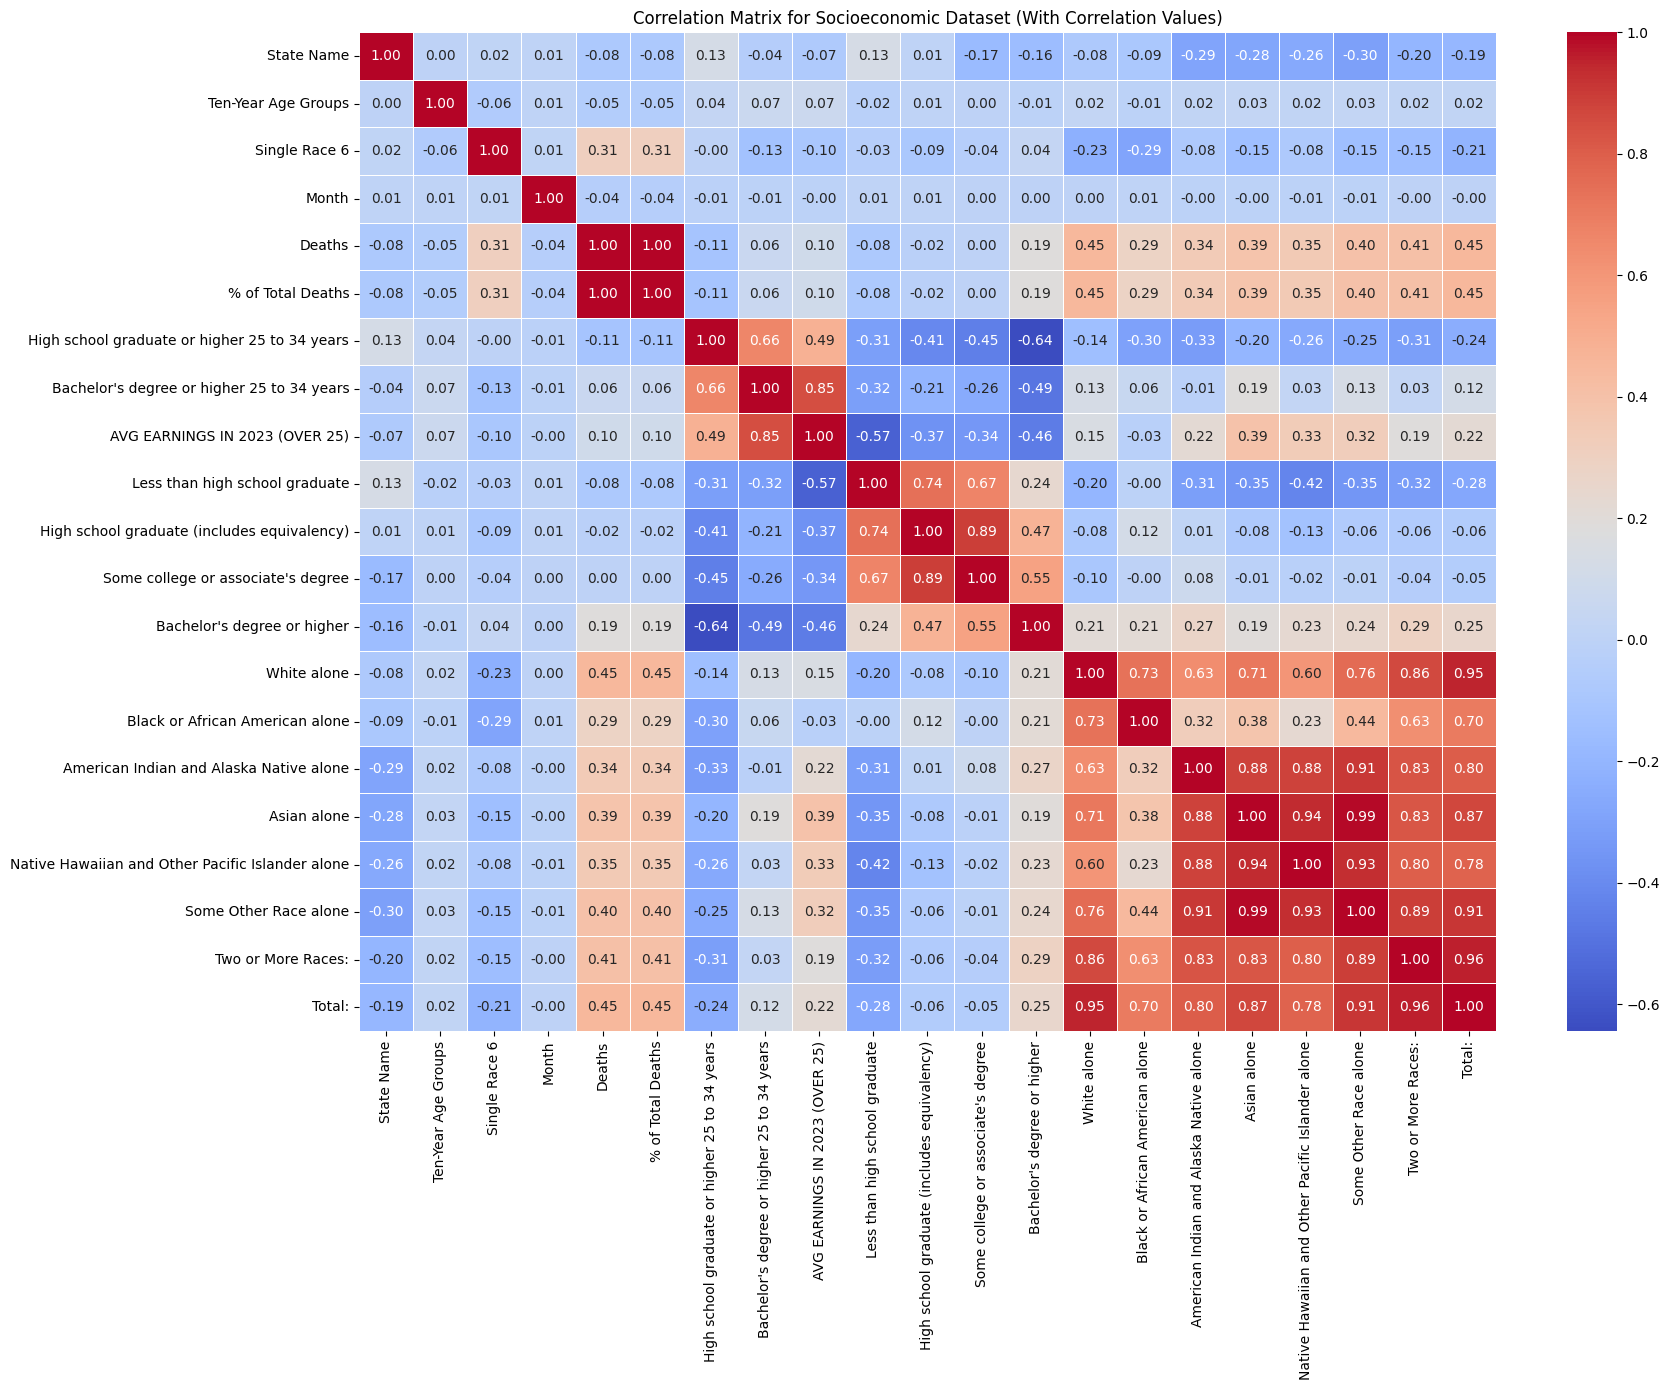

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

columns_of_interest = [
    'State Name', 'Ten-Year Age Groups', 'Single Race 6', 'Month', 'Deaths',
    '% of Total Deaths', 'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years", 'AVG EARNINGS IN 2023 (OVER 25)',
    'Less than high school graduate', 'High school graduate (includes equivalency)',
    'Some college or associate\'s degree', 'Bachelor\'s degree or higher',
    'White alone', 'Black or African American alone', 'American Indian and Alaska Native alone',
    'Asian alone', 'Native Hawaiian and Other Pacific Islander alone', 'Some Other Race alone',
    'Two or More Races:', 'Total:'
]

df = df[columns_of_interest]

df['State Name'] = df['State Name'].astype('category').cat.codes
df['Ten-Year Age Groups'] = df['Ten-Year Age Groups'].astype('category').cat.codes
df['Single Race 6'] = df['Single Race 6'].astype('category').cat.codes

categorical_cols = df.select_dtypes(include=['category']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df = df.dropna(axis=0, how='all')

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Socioeconomic Dataset (With Correlation Values)")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

total_deaths = df['Deaths'].sum()

print(f"Total Number of Deaths: {total_deaths}")


Total Number of Deaths: 89546


Index(['State Name', 'Ten-Year Age Groups', 'Single Race 6', 'Year', 'Month',
       'Deaths', '% of Total Deaths',
       'High school graduate or higher 25 to 34 years',
       'Bachelor's degree or higher 25 to 34 years',
       'AVG EARNINGS IN 2023 (OVER 25)', 'Less than high school graduate',
       'High school graduate (includes equivalency)',
       'Some college or associate's degree', 'Bachelor's degree or higher',
       'White alone', 'Black or African American alone',
       'American Indian and Alaska Native alone', 'Asian alone',
       'Native Hawaiian and Other Pacific Islander alone',
       'Some Other Race alone', 'Two or More Races:'],
      dtype='object')


<ipython-input-11-5d2c78f37b38>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deaths', y='State Name', data=state_deaths_sorted, palette='viridis')


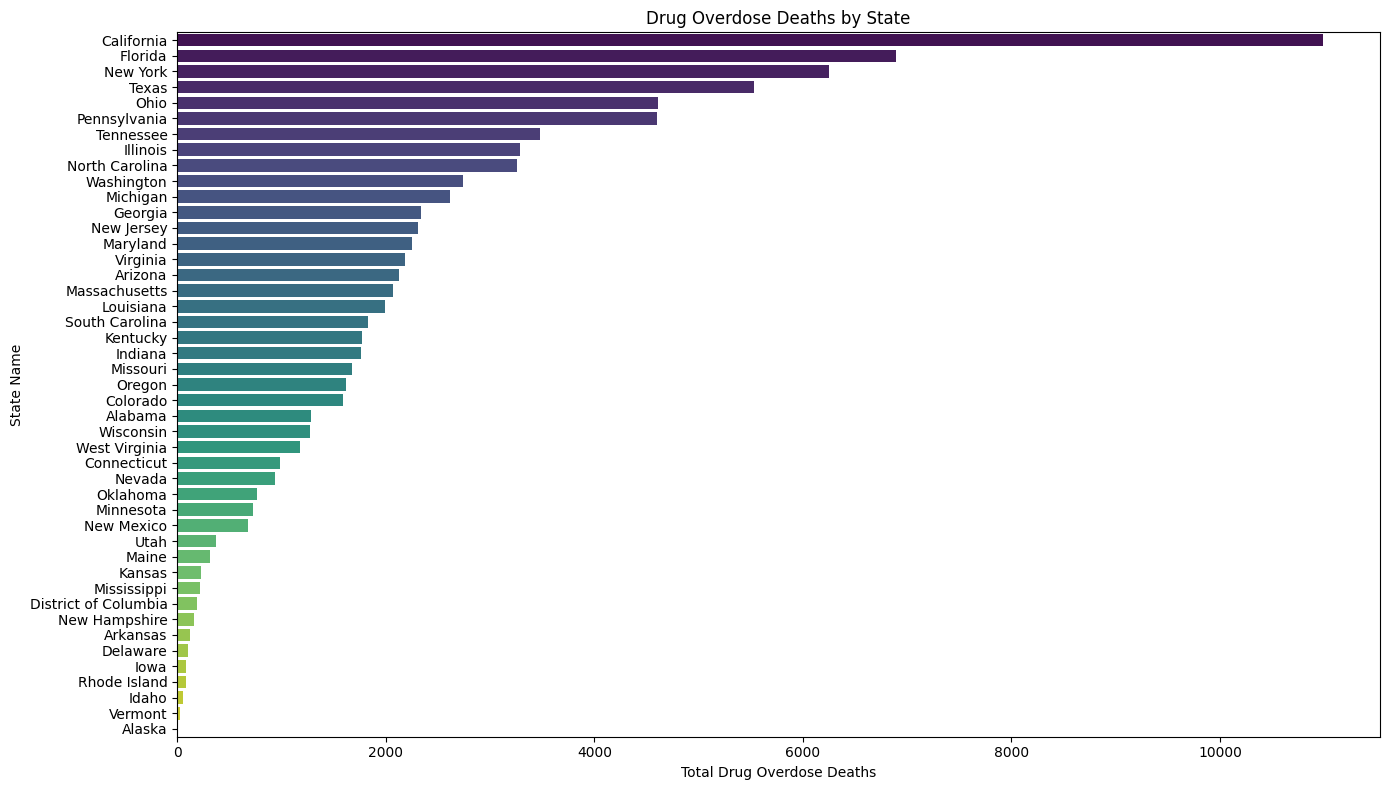

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vssr = pd.read_excel("/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx", sheet_name=None)

vssr_main = next((sheet for sheet in vssr.values() if {'State Name', 'Deaths'}.issubset(sheet.columns)), None)

print(vssr_main.columns)

state_deaths = vssr_main.groupby('State Name')['Deaths'].sum().reset_index()

state_deaths_sorted = state_deaths.sort_values(by='Deaths', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='Deaths', y='State Name', data=state_deaths_sorted, palette='viridis')
plt.title('Drug Overdose Deaths by State')
plt.xlabel('Total Drug Overdose Deaths')
plt.ylabel('State Name')
plt.tight_layout()
plt.show()

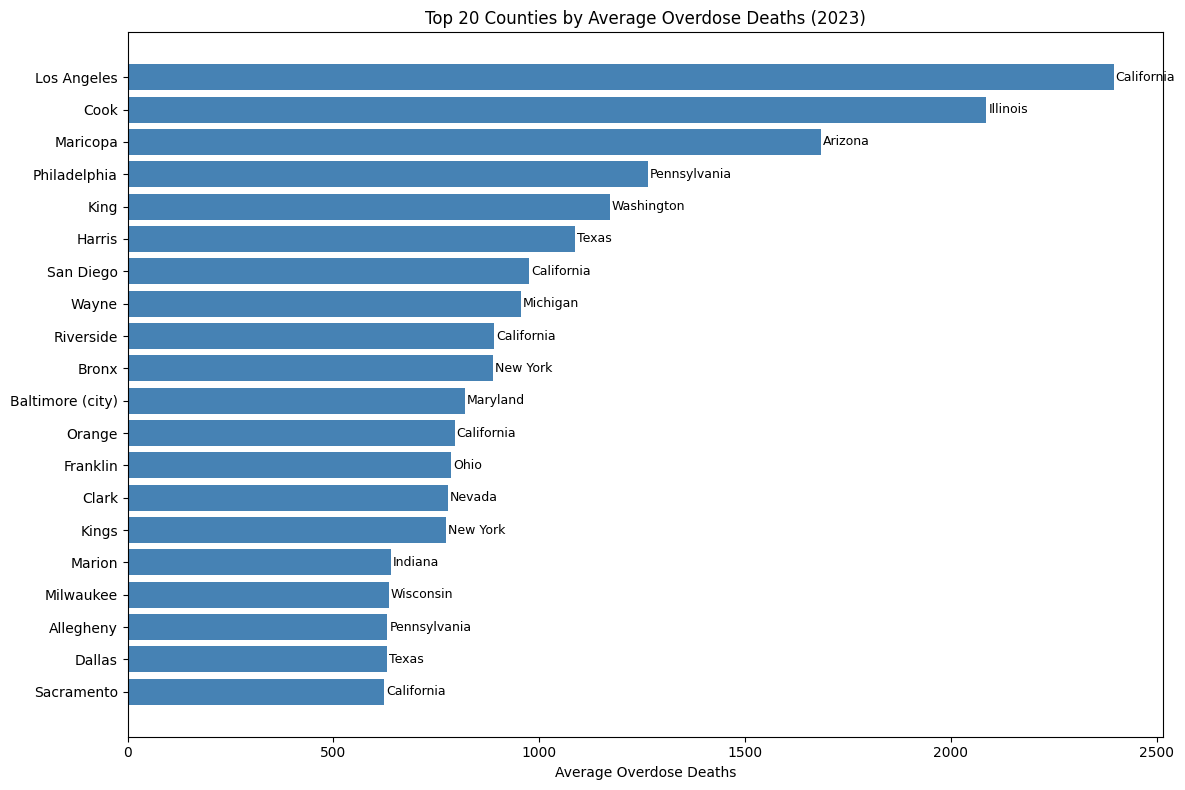

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx'
df = pd.read_excel(file_path)

avg_deaths = df.groupby(['STATE_NAME', 'COUNTYNAME'])['Provisional Drug Overdose Deaths'].mean().reset_index()

top_20 = avg_deaths.sort_values(by='Provisional Drug Overdose Deaths', ascending=False).head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_20['COUNTYNAME'], top_20['Provisional Drug Overdose Deaths'], color='steelblue')
plt.xlabel('Average Overdose Deaths')
plt.title('Top 20 Counties by Average Overdose Deaths (2023)')
plt.gca().invert_yaxis()

for bar, state in zip(bars, top_20['STATE_NAME']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             state, va='center', fontsize=9)

plt.tight_layout()
plt.show()

<ipython-input-1-24426e72f635>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Overdose Rate', y='State Name', data=state_overdose_rate_sorted, palette='viridis')


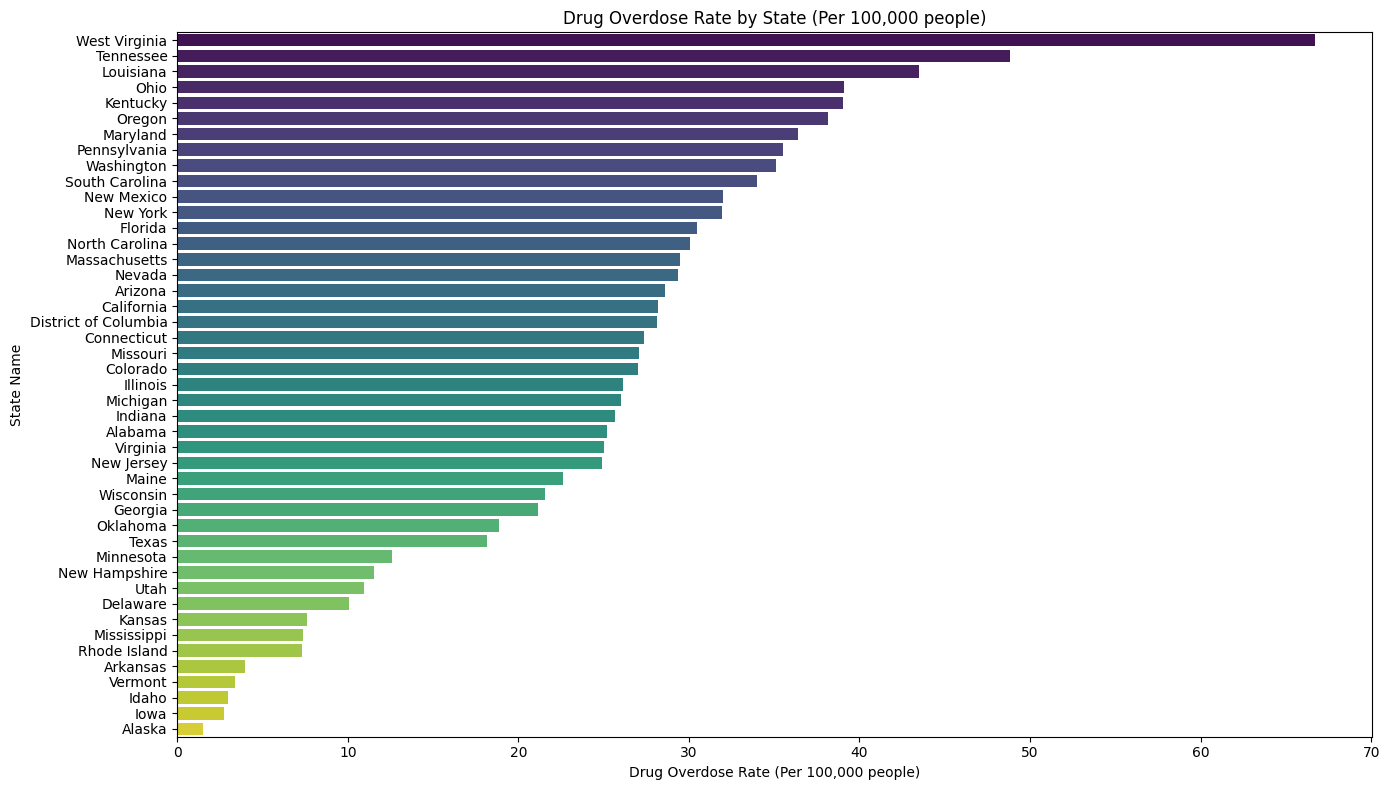

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vssr = pd.read_excel("/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx", sheet_name=None)

vssr_main = next((sheet for sheet in vssr.values() if {'State Name', 'Deaths', 'Total:'}.issubset(sheet.columns)), None)

vssr_main['Overdose Rate'] = (vssr_main['Deaths'] / vssr_main['Total:']) * 100000

state_overdose_rate = vssr_main.groupby('State Name')['Overdose Rate'].sum().reset_index()

state_overdose_rate_sorted = state_overdose_rate.sort_values(by='Overdose Rate', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='Overdose Rate', y='State Name', data=state_overdose_rate_sorted, palette='viridis')
plt.title('Drug Overdose Rate by State (Per 100,000 people)')
plt.xlabel('Drug Overdose Rate (Per 100,000 people)')
plt.ylabel('State Name')
plt.tight_layout()
plt.show()

<ipython-input-18-6478ba4e70ea>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='70% of Total Deaths', y='State Name', data=state_deaths_sorted, palette='viridis')


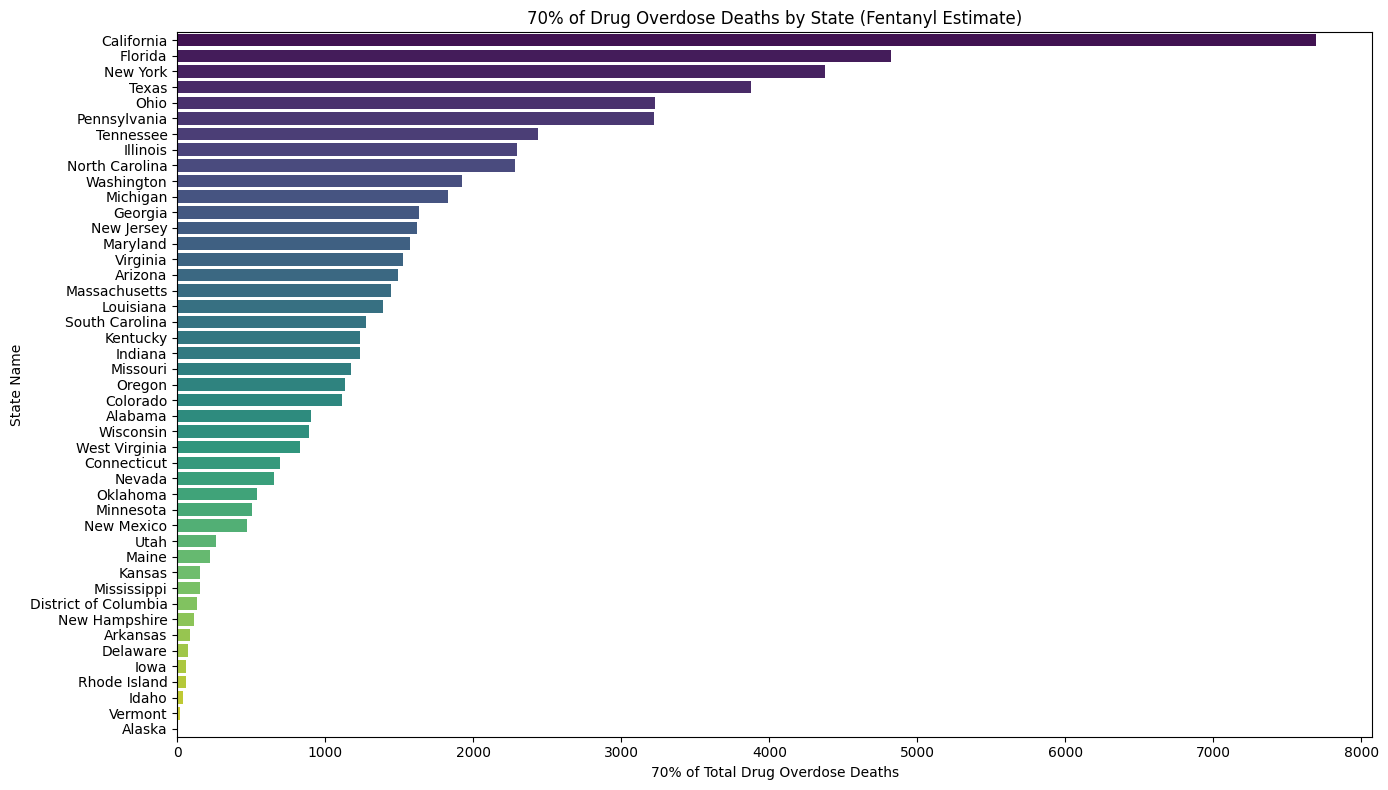

In [ ]:
i#Fentanyl Overdose Estimate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


vssr = pd.read_excel("/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx", sheet_name=None)

vssr_main = next((sheet for sheet in vssr.values() if {'State Name', 'Deaths'}.issubset(sheet.columns)), None)

state_deaths = vssr_main.groupby('State Name')['Deaths'].sum().reset_index()

state_deaths['70% of Total Deaths'] = state_deaths['Deaths'] * 0.7

state_deaths_sorted = state_deaths.sort_values(by='70% of Total Deaths', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='70% of Total Deaths', y='State Name', data=state_deaths_sorted, palette='viridis')

plt.title('70% of Drug Overdose Deaths by State (Fentanyl Estimate)')
plt.xlabel('70% of Total Drug Overdose Deaths')
plt.ylabel('State Name')
plt.tight_layout()
plt.show()

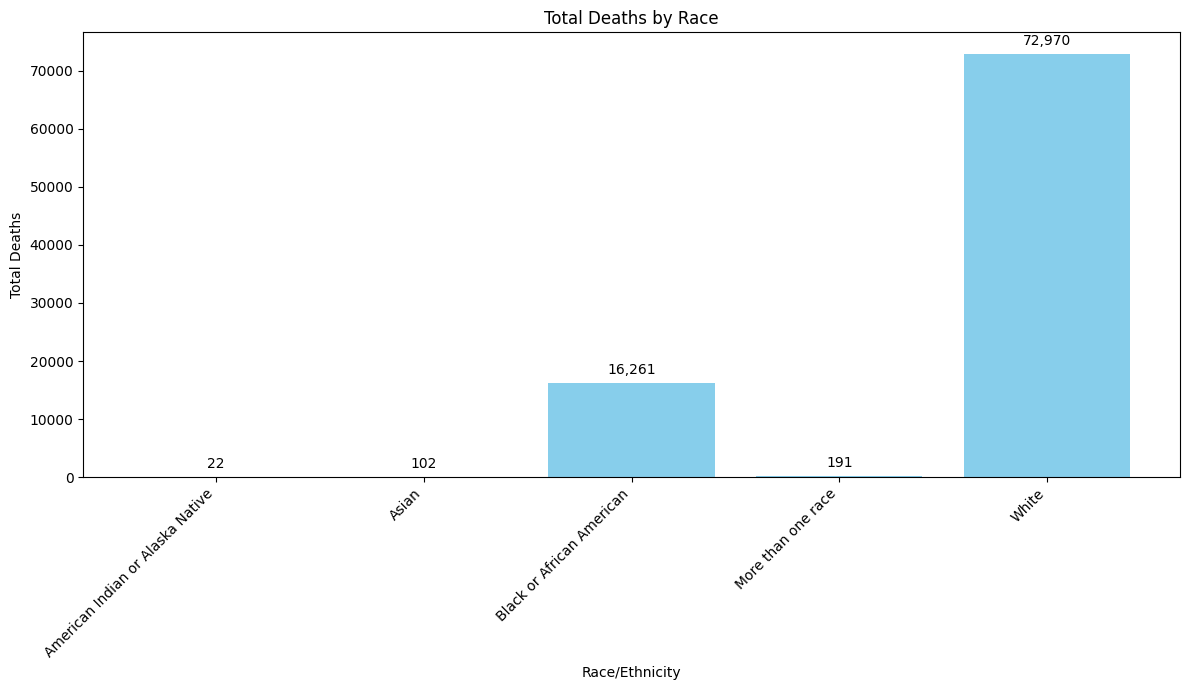

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

deaths_by_race = df.groupby('Single Race 6')['Deaths'].sum().reset_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(deaths_by_race['Single Race 6'], deaths_by_race['Deaths'], color='skyblue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1000, f'{int(yval):,}', ha='center', va='bottom')

plt.xlabel('Race/Ethnicity')
plt.ylabel('Total Deaths')
plt.title('Total Deaths by Race')
plt.xticks(rotation=45, ha='right')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

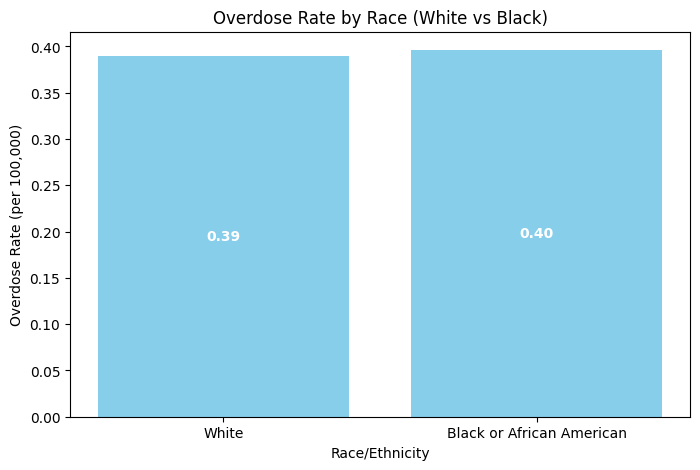

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

state_population = df.groupby('State Name')[['White alone', 'Black or African American alone']].sum()

white_deaths = df[df['Single Race 6'] == 'White']['Deaths'].sum()
black_deaths = df[df['Single Race 6'] == 'Black or African American']['Deaths'].sum()

white_population = state_population['White alone'].sum()
black_population = state_population['Black or African American alone'].sum()

white_rate = (white_deaths / white_population) * 100000
black_rate = (black_deaths / black_population) * 100000

race_data = {
    'Race/Ethnicity': ['White', 'Black or African American'],
    'Overdose Rate': [white_rate, black_rate]
}

race_deaths_df = pd.DataFrame(race_data)

plt.figure(figsize=(8, 5))
plt.bar(race_deaths_df['Race/Ethnicity'], race_deaths_df['Overdose Rate'], color='skyblue')

for i, v in enumerate(race_deaths_df['Overdose Rate']):
    plt.text(
        i,
        v / 2,
        f'{v:.2f}',
        ha='center',
        va='center',
        color='white',
        fontweight='bold'
    )

plt.xlabel('Race/Ethnicity')
plt.ylabel('Overdose Rate (per 100,000)')
plt.title('Overdose Rate by Race (White vs Black)')
plt.show()

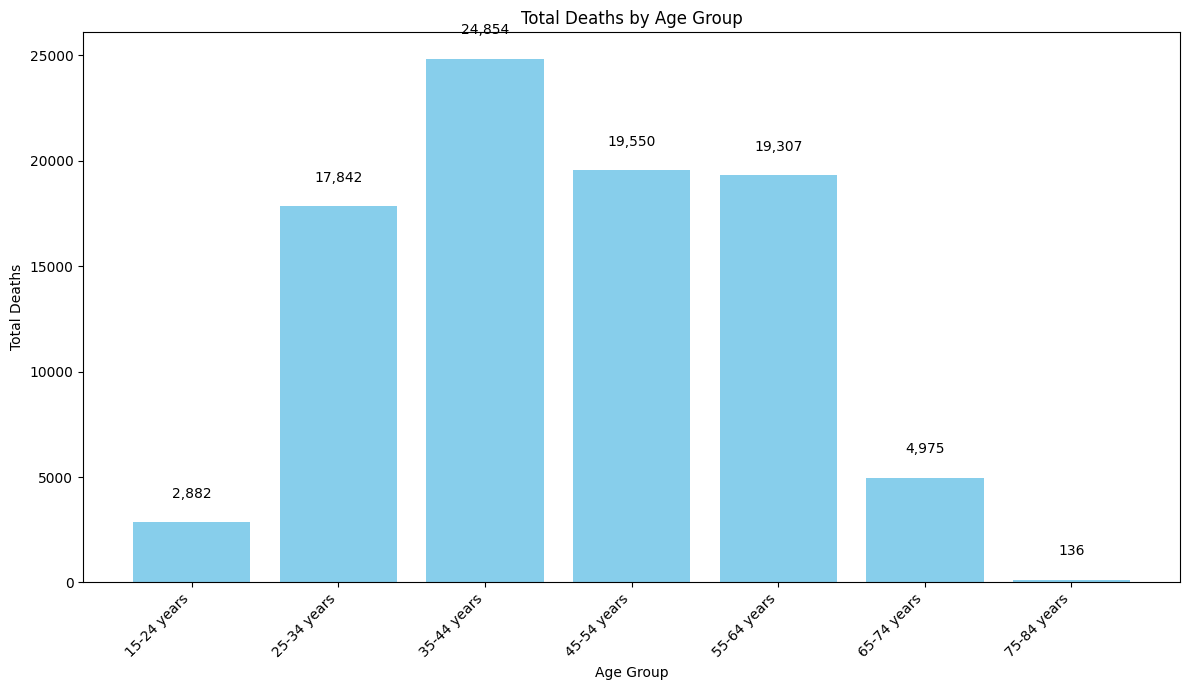

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

deaths_by_age_group = df.groupby('Ten-Year Age Groups')['Deaths'].sum().reset_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(deaths_by_age_group['Ten-Year Age Groups'], deaths_by_age_group['Deaths'], color='skyblue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1000, f'{int(yval):,}', ha='center', va='bottom')

plt.xlabel('Age Group')
plt.ylabel('Total Deaths')
plt.title('Total Deaths by Age Group')
plt.xticks(rotation=45, ha='right')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

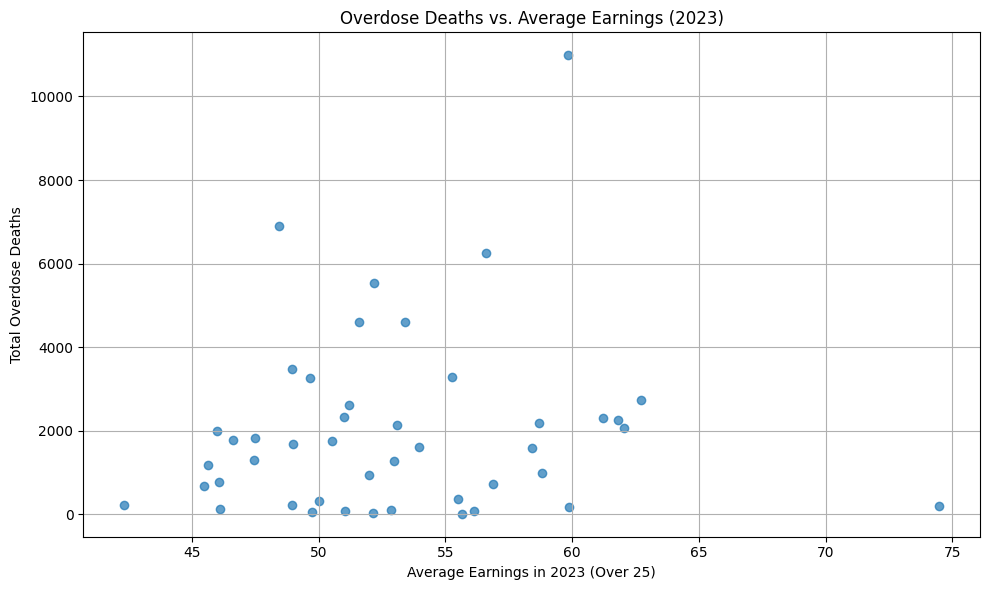

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

df['AVG EARNINGS IN 2023 (OVER 25)'] = pd.to_numeric(df['AVG EARNINGS IN 2023 (OVER 25)'], errors='coerce')

income_death_sum = df.groupby('AVG EARNINGS IN 2023 (OVER 25)')['Deaths'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(income_death_sum['AVG EARNINGS IN 2023 (OVER 25)'], income_death_sum['Deaths'], alpha=0.7)
plt.title('Overdose Deaths vs. Average Earnings (2023)')
plt.xlabel('Average Earnings in 2023 (Over 25)')
plt.ylabel('Total Overdose Deaths')
plt.grid(True)
plt.tight_layout()
plt.show()

models

Random Forest

R² Score: 0.9353
Mean Absolute Error: 4.885643
Root Mean Squared Error: 7.166137
Feature Importances:
                                             Feature  Importance
19                    State_Month_Provisional_Deaths    0.359867
1                                Ten-Year Age Groups    0.299488
2                                      Single Race 6    0.253115
3                                              Month    0.020218
18                                            Total:    0.008819
16                             Some Other Race alone    0.007904
11                                       White alone    0.007438
0                                         State Name    0.007373
17                                Two or More Races:    0.007069
13           American Indian and Alaska Native alone    0.004173
15  Native Hawaiian and Other Pacific Islander alone    0.003830
12                   Black or African American alone    0.003751
7                     Less than high school graduate 

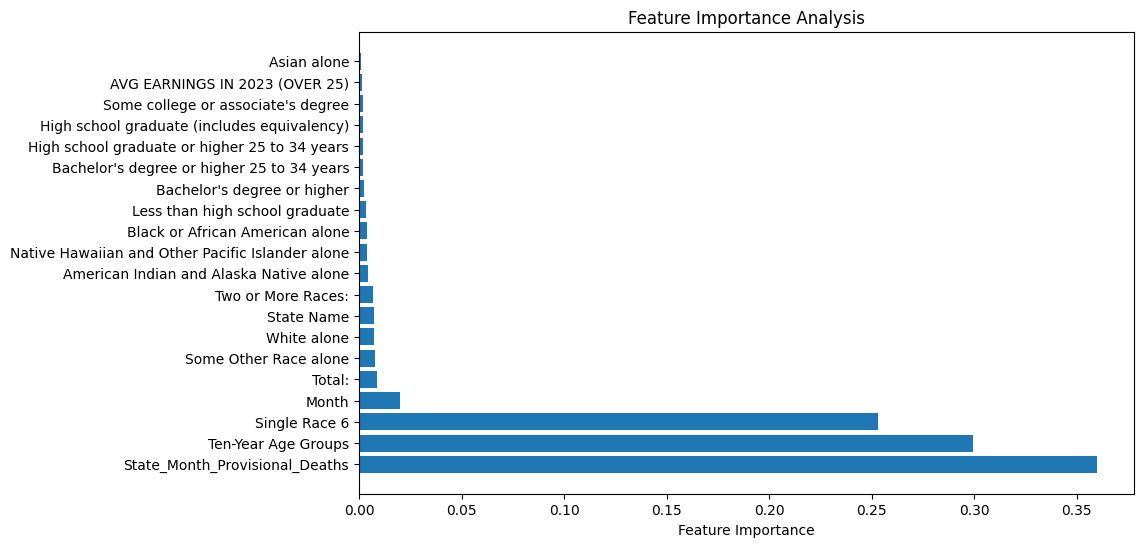

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

main_df = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx')
new_df = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx')

aggregated_new_df = new_df.groupby(['STATE_NAME', 'Month'])['Provisional Drug Overdose Deaths'].sum().reset_index()
aggregated_new_df.rename(columns={'STATE_NAME': 'State Name', 'Provisional Drug Overdose Deaths': 'State_Month_Provisional_Deaths'}, inplace=True)

state_month_mapping = dict(zip(zip(aggregated_new_df['State Name'], aggregated_new_df['Month']), aggregated_new_df['State_Month_Provisional_Deaths']))
main_df['State_Month_Provisional_Deaths'] = main_df.apply(lambda row: state_month_mapping.get((row['State Name'], row['Month']), 0), axis=1)

le_state = LabelEncoder()
le_age = LabelEncoder()
le_race = LabelEncoder()

main_df['State Name'] = le_state.fit_transform(main_df['State Name'])
main_df['Ten-Year Age Groups'] = le_age.fit_transform(main_df['Ten-Year Age Groups'])
main_df['Single Race 6'] = le_race.fit_transform(main_df['Single Race 6'])

feature_columns = [col for col in main_df.columns if col not in ['Deaths', 'Year', '% of Total Deaths']]

X = main_df[feature_columns]
y = main_df['Deaths']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

best_rf_model = RandomForestRegressor(random_state=42)
best_rf_model.fit(X_train, y_train)

y_pred = best_rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.6f}")
print(f"Root Mean Squared Error: {rmse:.6f}")

importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance Analysis')
plt.show()

Lasso regression

Best Alpha (Regularization): 0.10476157527896651
R² Score: 0.7591
Mean Absolute Error: 9.425677
Root Mean Squared Error: 13.832554

Top 20 Feature Importance from Lasso Regression:
                                               Feature  Coefficient  \
17                               Single Race 6 Encoded    20.647054   
18                      State_Month_Provisional_Deaths    18.443202   
220                      Ten-Year Age Groups Encoded^2   -12.179947   
224                            Single Race 6 Encoded^2    10.050703   
225  Single Race 6 Encoded State_Month_Provisional_...     9.692803   
91   High school graduate (includes equivalency) Si...    -4.969063   
221  Ten-Year Age Groups Encoded Single Race 6 Encoded    -3.465230   
14                                         White alone     2.452863   
107  Bachelor's degree or higher Single Race 6 Encoded     2.001984   
136  Less than high school graduate Single Race 6 E...     1.776989   
199           Two or More Races: Singl

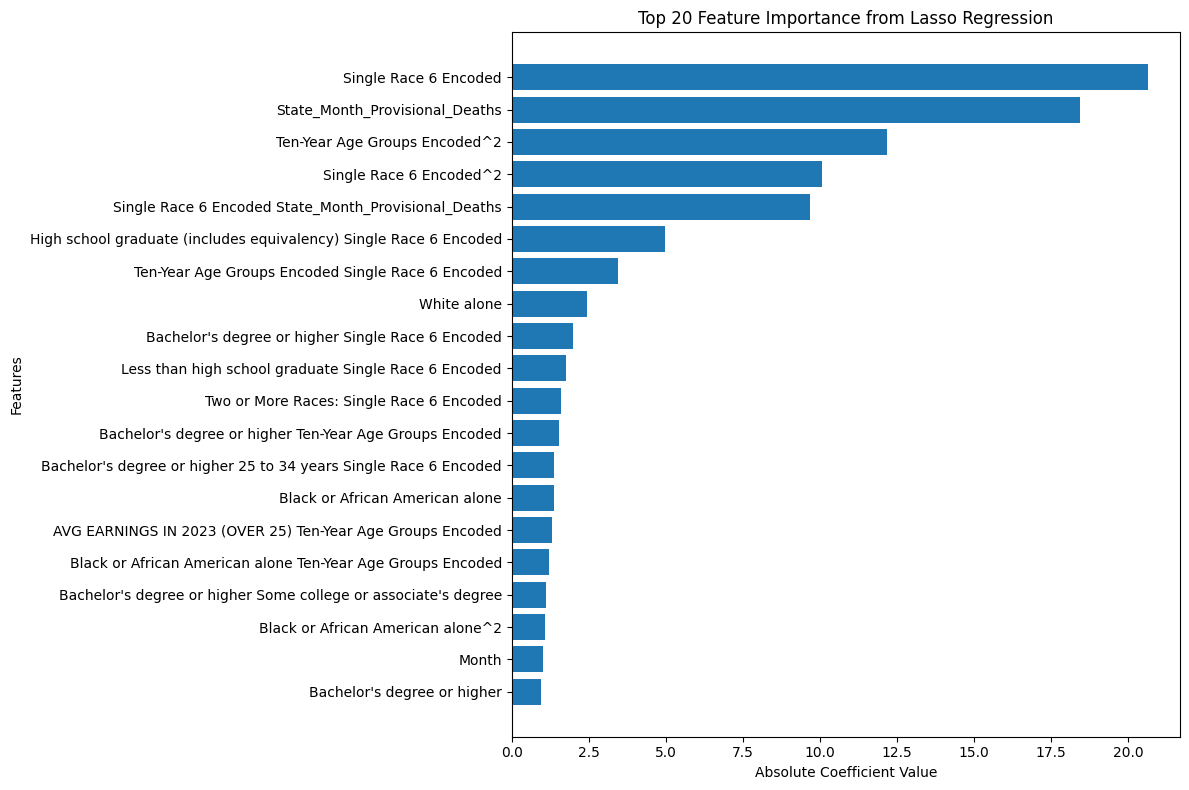

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

new_data = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx')

aggregated_new_data = new_data.groupby(['STATE_NAME', 'Month'])['Provisional Drug Overdose Deaths'].sum().reset_index()
aggregated_new_data.rename(columns={'STATE_NAME': 'State Name', 'Provisional Drug Overdose Deaths': 'State_Month_Provisional_Deaths'}, inplace=True)

state_month_mapping = dict(zip(zip(aggregated_new_data['State Name'], aggregated_new_data['Month']),
                               aggregated_new_data['State_Month_Provisional_Deaths']))

df['State_Month_Provisional_Deaths'] = df.apply(lambda row: state_month_mapping.get((row['State Name'], row['Month']), 0), axis=1)

label_encoder = LabelEncoder()
df['State Name Encoded'] = label_encoder.fit_transform(df['State Name'])
df['Ten-Year Age Groups Encoded'] = df['Ten-Year Age Groups'].astype('category').cat.codes
df['Single Race 6 Encoded'] = df['Single Race 6'].astype('category').cat.codes

percentage_columns = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'Less than high school graduate',
    'High school graduate (includes equivalency)',
    'Some college or associate\'s degree',
    'Bachelor\'s degree or higher'
]

features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'State Name Encoded',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'Ten-Year Age Groups Encoded',
    'Single Race 6 Encoded',
    'State_Month_Provisional_Deaths',
    'Total:'
]

target = 'Deaths'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

alphas = np.logspace(-3, 1, 100)
lasso_model = LassoCV(alphas=alphas, max_iter=800000, cv=5, random_state=42, n_jobs=-1)

lasso_model.fit(X_train, y_train)

best_alpha = lasso_model.alpha_
print(f"Best Alpha (Regularization): {best_alpha}")

y_pred = lasso_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.6f}")
print(f"Root Mean Squared Error: {rmse:.6f}")

coef = lasso_model.coef_
feature_names = poly.get_feature_names_out(features)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Absolute Coefficient': np.abs(coef)
})

feature_importance_df = feature_importance_df.sort_values(by='Absolute Coefficient', ascending=False)
non_zero_features = feature_importance_df[feature_importance_df['Absolute Coefficient'] > 0]

print("\nTop 20 Feature Importance from Lasso Regression:")
print(non_zero_features.head(20))


plt.figure(figsize=(12, 8))
plt.barh(non_zero_features['Feature'].head(20)[::-1],
         non_zero_features['Absolute Coefficient'].head(20)[::-1])
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Features')
plt.title('Top 20 Feature Importance from Lasso Regression')
plt.tight_layout()
plt.show()

XGBoost

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}

XGBoost Performance:
R² Score: 0.9433
Mean Absolute Error (MAE): 4.8108
Root Mean Squared Error (RMSE): 6.7090


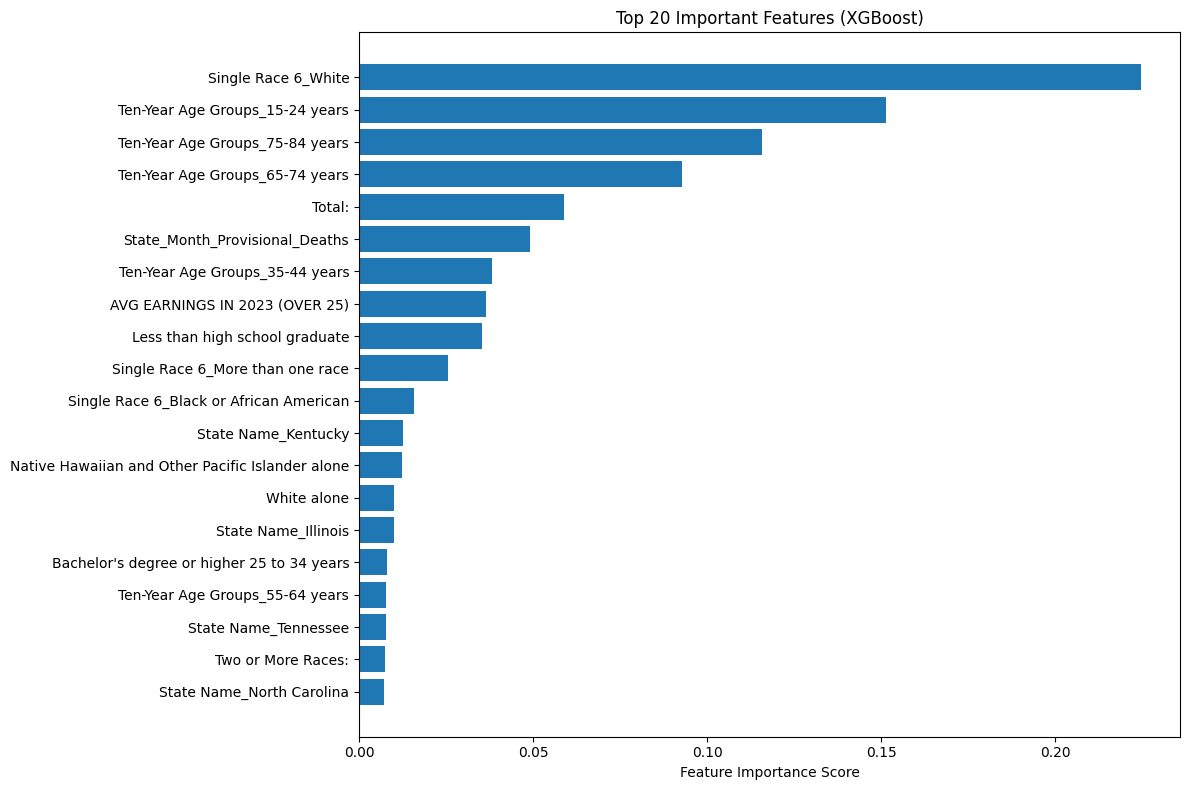

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

new_data = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx')

aggregated_new_data = new_data.groupby(['STATE_NAME', 'Month'])['Provisional Drug Overdose Deaths'].sum().reset_index()
aggregated_new_data.rename(columns={'STATE_NAME': 'State Name', 'Provisional Drug Overdose Deaths': 'State_Month_Provisional_Deaths'}, inplace=True)

state_month_mapping = dict(zip(zip(aggregated_new_data['State Name'], aggregated_new_data['Month']),
                               aggregated_new_data['State_Month_Provisional_Deaths']))
df['State_Month_Provisional_Deaths'] = df.apply(lambda row: state_month_mapping.get((row['State Name'], row['Month']), 0), axis=1)

features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'State Name',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'Ten-Year Age Groups',
    'Single Race 6',
    'State_Month_Provisional_Deaths',
    'Total:'
]
target = 'Deaths'

X = df[features]
y = df[target]

numeric_features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'State_Month_Provisional_Deaths',
    'Total:'
]
categorical_features = ['State Name', 'Ten-Year Age Groups', 'Single Race 6']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

y_pred = best_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nXGBoost Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

feature_importances = best_xgb.feature_importances_
feature_names = numeric_features + list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Important Features (XGBoost)')
plt.tight_layout()
plt.show()

Stacking - Random Forest and XGBoost

Fitting 3 folds for each of 32 candidates, totalling 96 fits
R² Score: 0.9371
Mean Absolute Error: 4.889194
Root Mean Squared Error: 7.065669


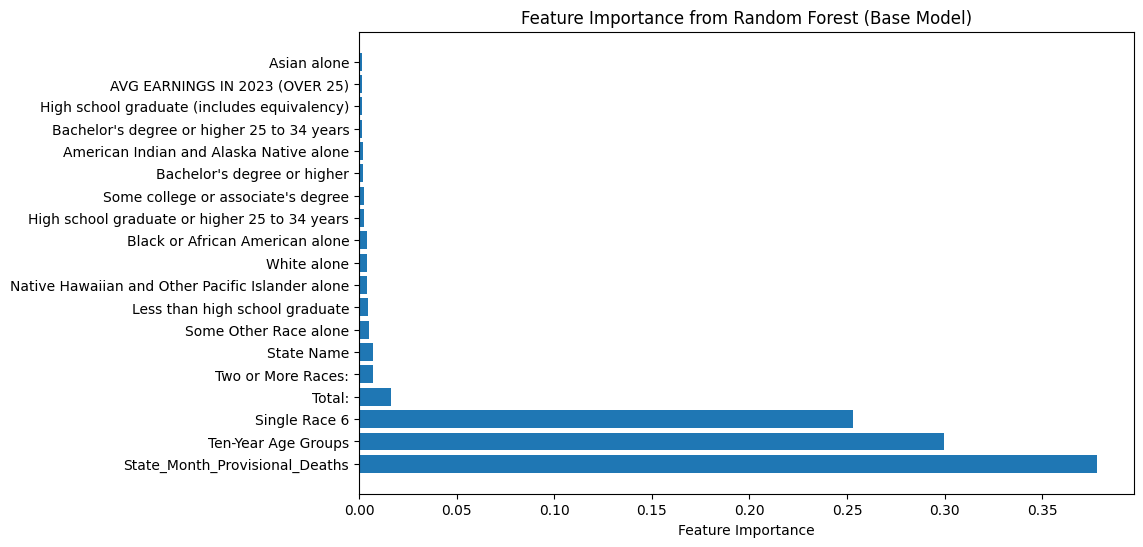

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

main_df = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx')
new_df = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx')

aggregated_new_df = new_df.groupby(['STATE_NAME', 'Month'])['Provisional Drug Overdose Deaths'].sum().reset_index()
aggregated_new_df.rename(columns={'STATE_NAME': 'State Name', 'Provisional Drug Overdose Deaths': 'State_Month_Provisional_Deaths'}, inplace=True)

state_month_mapping = dict(zip(zip(aggregated_new_df['State Name'], aggregated_new_df['Month']), aggregated_new_df['State_Month_Provisional_Deaths']))
main_df['State_Month_Provisional_Deaths'] = main_df.apply(lambda row: state_month_mapping.get((row['State Name'], row['Month']), 0), axis=1)

le_state = LabelEncoder()
le_age = LabelEncoder()
le_race = LabelEncoder()

main_df['State Name'] = le_state.fit_transform(main_df['State Name'])
main_df['Ten-Year Age Groups'] = le_age.fit_transform(main_df['Ten-Year Age Groups'])
main_df['Single Race 6'] = le_race.fit_transform(main_df['Single Race 6'])

feature_columns = [col for col in main_df.columns if col not in ['Deaths', 'Year', 'Month', '% of Total Deaths']]
X = main_df[feature_columns]
y = main_df['Deaths']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

base_learners = [
    ('xgb', best_xgb_model),
    ('rf', rf_model)
]

meta_model = LinearRegression()

stacking_model = StackingRegressor(estimators=base_learners, final_estimator=meta_model)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.6f}")
print(f"Root Mean Squared Error: {rmse:.6f}")

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance from Random Forest (Base Model)')
plt.show()

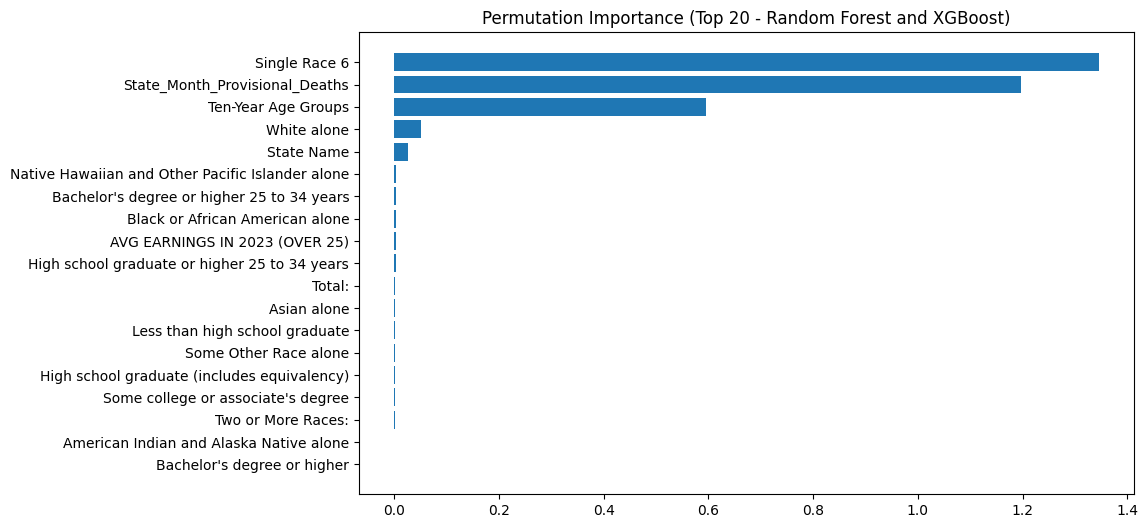

In [2]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    stacking_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(
    np.array(feature_columns)[sorted_idx],
    result.importances_mean[sorted_idx]
)
plt.title("Permutation Importance (Top 20 - Random Forest and XGBoost)")
plt.show()

XGBoost SVR

XGBoost + SVR Stacked Model Performance:
R² Score: 0.9446
MAE: 4.7806
RMSE: 6.6331


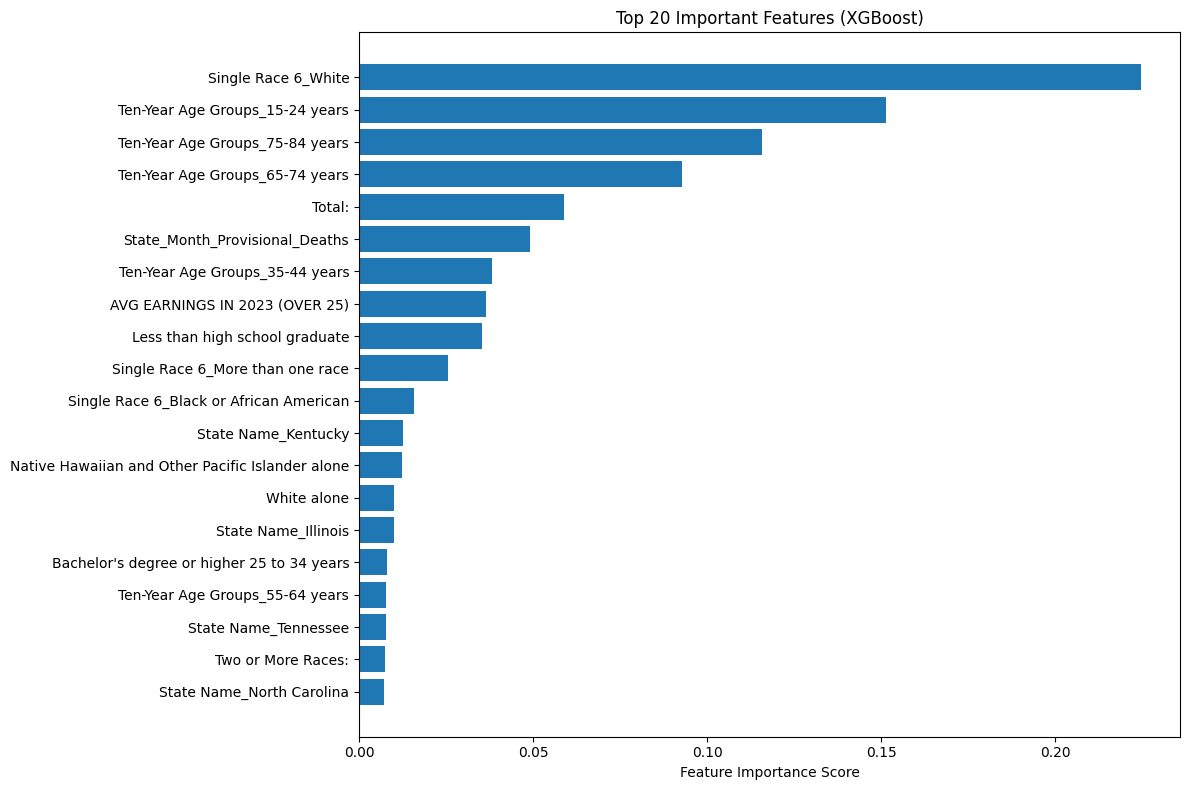

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

df = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx')
new_data = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx')

agg = new_data.groupby(['STATE_NAME', 'Month'])['Provisional Drug Overdose Deaths'].sum().reset_index()
agg.rename(columns={'STATE_NAME': 'State Name', 'Provisional Drug Overdose Deaths': 'State_Month_Provisional_Deaths'}, inplace=True)
mapping = dict(zip(zip(agg['State Name'], agg['Month']), agg['State_Month_Provisional_Deaths']))
df['State_Month_Provisional_Deaths'] = df.apply(lambda row: mapping.get((row['State Name'], row['Month']), 0), axis=1)


features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'State Name',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'Ten-Year Age Groups',
    'Single Race 6',
    'State_Month_Provisional_Deaths',
    'Total:'
]
target = 'Deaths'

X = df[features]
y = df[target]

numeric_features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'State_Month_Provisional_Deaths',
    'Total:'
]
categorical_features = ['State Name', 'Ten-Year Age Groups', 'Single Race 6']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    colsample_bytree=0.9,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=0.9
)
xgb_model.fit(X_train, y_train)

svr_model = SVR(kernel='rbf', C=10, epsilon=1.0)
svr_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
svr_preds = svr_model.predict(X_test)

stacked_input = np.vstack([xgb_preds, svr_preds]).T
meta_model = LinearRegression()
meta_model.fit(stacked_input, y_test)
final_preds = meta_model.predict(stacked_input)

r2 = r2_score(y_test, final_preds)
mae = mean_absolute_error(y_test, final_preds)
rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print("XGBoost + SVR Stacked Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

importances = xgb_model.feature_importances_
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'].head(20)[::-1], feature_importance_df['Importance'].head(20)[::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Important Features (XGBoost)')
plt.tight_layout()
plt.show()

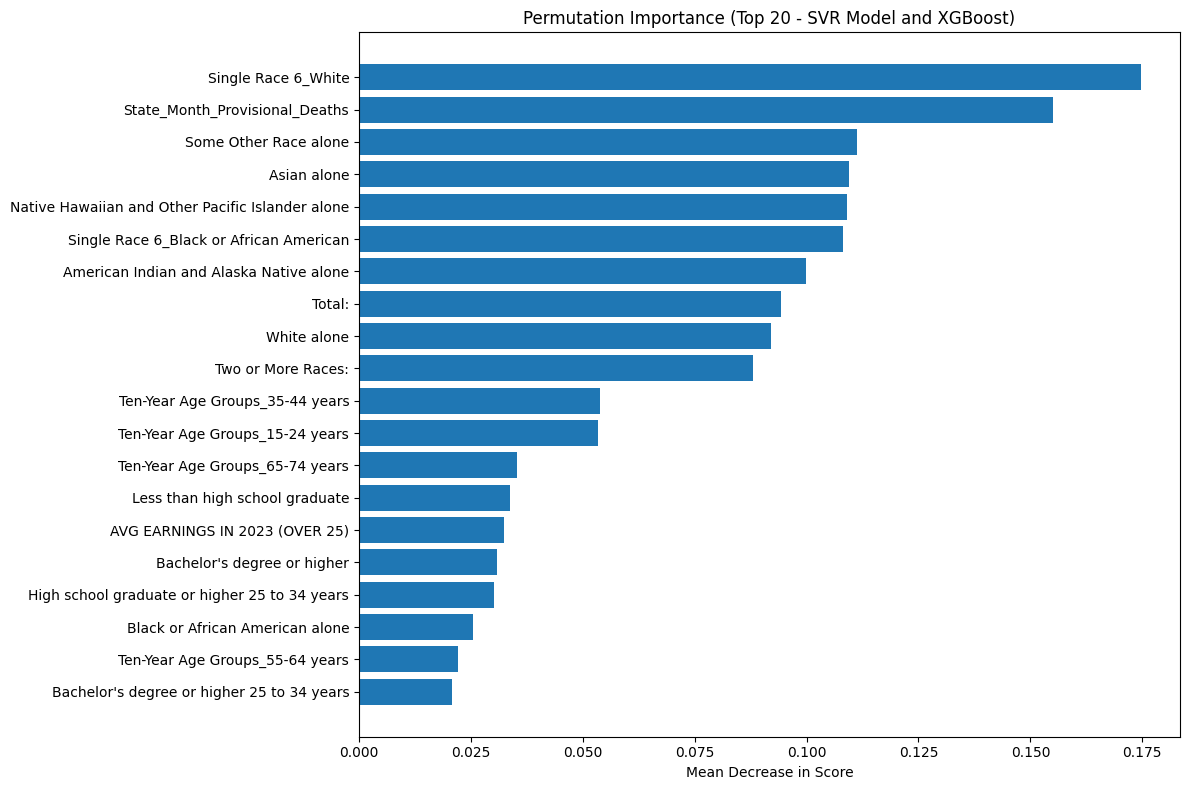

In [ ]:
result = permutation_importance(
    svr_model,
    X_test.toarray(),
    y_test,
    n_repeats=10,
    random_state=42
)

feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

sorted_idx = result.importances_mean.argsort()[-20:]

plt.figure(figsize=(12, 8))
plt.barh(np.array(feature_names)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel('Mean Decrease in Score')
plt.title('Permutation Importance (Top 20 - SVR Model and XGBoost)')
plt.tight_layout()
plt.show()

In [7]:
# Exporting my predictions as a CSV
final_preds = meta_model.predict(stacked_input)

original_states = df.loc[y_test.index, 'State Name'].reset_index(drop=True)
original_months = df.loc[y_test.index, 'Month'].reset_index(drop=True)

state_monthly_results = pd.DataFrame({
    'State Name': original_states,
    'Month': original_months,
    'Actual Deaths': y_test.reset_index(drop=True),
    'Predicted Deaths': final_preds
})

state_monthly_summary = state_monthly_results.groupby(['State Name', 'Month']).sum().reset_index()

state_monthly_summary.to_csv('/content/Best_SVR_Bstate_monthly_predictions_stacked.csv', index=False)
print("Monthly state-level predictions exported to: /Best_SVR_content/state_monthly_predictions_stacked.csv")

print("\nMonthly Deaths by State (Actual vs. Predicted) using SVR and XGBoost Stacking:")
print(state_monthly_summary.head())

Monthly state-level predictions exported to: /Best_SVR_content/state_monthly_predictions_stacked.csv

Monthly Deaths by State (Actual vs. Predicted) using SVR and XGBoost Stacking:
  State Name  Month  Actual Deaths  Predicted Deaths
0    Alabama      1             25         23.397339
1    Alabama      2             27         22.947528
2    Alabama      3             75         72.800739
3    Alabama      4             36         32.762946
4    Alabama      6             28         32.346607


NN

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1422.5084 - mae: 27.0412 - val_loss: 595.8694 - val_mae: 17.4980
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 668.4905 - mae: 17.1295 - val_loss: 377.7979 - val_mae: 12.8523
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 474.9399 - mae: 14.1615 - val_loss: 294.5142 - val_mae: 11.2055
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 275.4400 - mae: 10.3641 - val_loss: 242.0222 - val_mae: 10.2173
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 217.0065 - mae: 9.1715 - val_loss: 191.4631 - val_mae: 9.1784
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 198.8290 - mae: 8.6078 - val_loss: 145.5750 - val_mae: 7.7257
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 143.9247 - mae: 7.4135 - val_loss: 124.6441 - val_mae: 7.2643
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 126.9052 - mae: 6.6437 - val_loss: 88.4191 - val_mae: 6.0864
Epoch 9/30
59/59 ━━━━━━━━━━━━━━

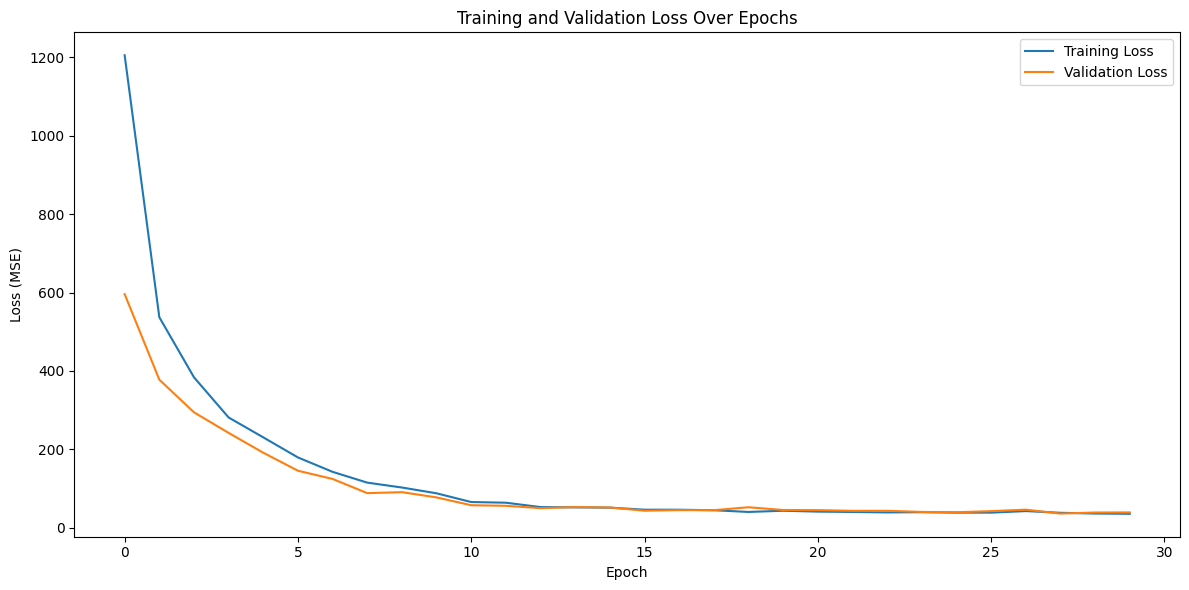

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Thesis/Datasets/Clean Data/socioeconomic_od.xlsx'
df = pd.read_excel(file_path)

new_data = pd.read_excel('/content/drive/MyDrive/Thesis/Datasets/Clean Data/cleaned_VSSR_County_Overdose_2023.xlsx')

aggregated_new_data = new_data.groupby(['STATE_NAME', 'Month'])['Provisional Drug Overdose Deaths'].sum().reset_index()
aggregated_new_data.rename(columns={'STATE_NAME': 'State Name', 'Provisional Drug Overdose Deaths': 'State_Month_Provisional_Deaths'}, inplace=True)

state_month_mapping = dict(zip(zip(aggregated_new_data['State Name'], aggregated_new_data['Month']),
                               aggregated_new_data['State_Month_Provisional_Deaths']))
df['State_Month_Provisional_Deaths'] = df.apply(lambda row: state_month_mapping.get((row['State Name'], row['Month']), 0), axis=1)


features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'State Name',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'Ten-Year Age Groups',
    'Single Race 6',
    'State_Month_Provisional_Deaths',
    'Total:'
]
target = 'Deaths'

X = df[features]
y = df[target]

numeric_features = [
    'High school graduate or higher 25 to 34 years',
    "Bachelor's degree or higher 25 to 34 years",
    'AVG EARNINGS IN 2023 (OVER 25)',
    'High school graduate (includes equivalency)',
    'Bachelor\'s degree or higher',
    'Some college or associate\'s degree',
    'Less than high school graduate',
    'Native Hawaiian and Other Pacific Islander alone',
    'American Indian and Alaska Native alone',
    'Black or African American alone',
    'Asian alone',
    'Two or More Races:',
    'Some Other Race alone',
    'White alone',
    'Month',
    'State_Month_Provisional_Deaths',
    'Total:'
]
categorical_features = ['State Name', 'Ten-Year Age Groups', 'Single Race 6']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

y_pred = model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nNeural Network Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

predictions_df = pd.DataFrame({
    'State Name': X_test['State Name'].reset_index(drop=True),
    'Month': X_test['Month'].reset_index(drop=True),
    'Actual Deaths': y_test.reset_index(drop=True),
    'Predicted Deaths': y_pred
})

In [ ]:
# Printing my predictions and exporting as csv
original_states = df.loc[y_test.index, 'State Name'].reset_index(drop=True)
original_months = df.loc[y_test.index, 'Month'].reset_index(drop=True)

state_monthly_results = pd.DataFrame({
    'State Name': original_states,
    'Month': original_months,
    'Actual Deaths': y_test.reset_index(drop=True),
    'Predicted Deaths': y_pred
})

state_monthly_summary = state_monthly_results.groupby(['State Name', 'Month']).sum().reset_index()

state_monthly_summary['State Name'] = state_monthly_summary['State Name'].apply(
    lambda x: le_state.inverse_transform([x])[0] if 'le_state' in globals() else x
)

state_monthly_summary.to_csv('/content/state_monthly_predictions.csv', index=False)
print("Monthly state-level predictions exported to: /content/state_monthly_predictions.csv")

print("\nMonthly Deaths by State (Actual vs. Predicted):")
print(state_monthly_summary.head())

Monthly state-level predictions exported to: /content/state_monthly_predictions.csv

Monthly Deaths by State (Actual vs. Predicted):
  State Name  Month  Actual Deaths  Predicted Deaths
0    Alabama      1             25         27.752548
1    Alabama      2             27         28.070213
2    Alabama      3             75         86.108421
3    Alabama      4             36         39.745365
4    Alabama      6             28         39.655136
